In [2]:

import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
import re
import numpy as np

In [3]:
data_dir = Path("../data")

# All 7 CSV files that share the 16-column schema
csv_files = [
    data_dir / "Core-Processors-1.8.csv",
    # data_dir / "Xeon-Processors-1.8.csv",
    data_dir / "Atom-Processors-1.9-16col.csv",
    data_dir / "Celeron-Processors-1.9-16col.csv",
    data_dir / "Core_Ultra-Processors-1.10-16col.csv",
    data_dir / "Intel-Processors-1.9-16col.csv",
    data_dir / "Pentium-Processors-1.9-16col.csv",
]



In [4]:
def classify_suffix(name):
    # Extract trailing letters after the last number
    m = re.search(r'(\d+)([A-Z]+[0-9]?)$', name)
    suffix = m.group(2) if m else ""
    
    # Group into power tiers
    if suffix in ("K", "KF", "KS", "X", "XE", "HK", "HX"):
        return "High Perf"
    elif suffix in ("H", "HQ", "HL", "HE", "QM", "MQ"):
        return "High Perf Mobile"
    elif suffix in ("U", "UM", "UL", "UE"):
        return "Ultra-Low Power"
    elif suffix == "Y":
        return "Extreme Low Power"
    elif suffix in ("T", "TE"):
        return "Power Optimized"
    elif suffix in ("N", "NT", "NTE"):
        return "Low Power"
    elif suffix in ("E", "EQ", "EC"):
        return "Embedded"
    elif suffix in ("F", "KF"):
        return "No Graphics"
    elif suffix in ("M",):
        return "Mobile (Legacy)"
    elif suffix in ("S", "P", "G", "G1", "G4", "G7"):
        return "Standard / Graphics"
    elif suffix in ("B", "R", "RE", "RK"):
        return "BGA / Soldered"
    else:
        return "Standard"  # includes no suffix






In [5]:
gen_map = {
    "Merom": "Core 2", "Conroe": "Core 2", "Kentsfield": "Core 2",
    "Wolfdale": "Core 2", "Yorkfield": "Core 2", "Penryn": "Core 2",
    "Bloomfield": "Nehalem", "Lynnfield": "Nehalem", "Nehalem EP": "Nehalem",
    "Nehalem EX": "Nehalem", "Gulftown": "Westmere", "Clarkdale": "Westmere",
    "Arrandale": "Westmere", "Westmere EP": "Westmere", "Westmere EX": "Westmere",
    "Sandy Bridge": "Sandy Bridge", "Sandy Bridge E": "Sandy Bridge",
    "Sandy Bridge EN": "Sandy Bridge", "Sandy Bridge EP": "Sandy Bridge",
    "Ivy Bridge": "Ivy Bridge", "Ivy Bridge E": "Ivy Bridge",
    "Ivy Bridge EN": "Ivy Bridge", "Ivy Bridge EP": "Ivy Bridge",
    "Haswell": "Haswell", "Haswell E": "Haswell",
    "Broadwell": "Broadwell", "Broadwell E": "Broadwell",
    "Skylake": "Skylake", "Kaby Lake": "Kaby Lake",
    "Kaby Lake G": "Kaby Lake", "Kaby Lake R": "Kaby Lake",
    "Coffee Lake": "Coffee Lake", "Comet Lake": "Comet Lake",
    "Whiskey Lake": "Whiskey Lake", "Amber Lake": "Amber Lake",
    "Amber Lake Y": "Amber Lake", "Ice Lake": "Ice Lake",
    "Tiger Lake": "Tiger Lake", "Rocket Lake": "Rocket Lake",
    "Alder Lake": "Alder Lake", "Alder Lake-N": "Alder Lake",
    "Raptor Lake": "Raptor Lake", "Meteor Lake": "Meteor Lake",
    "Lunar Lake": "Lunar Lake", "Arrow Lake": "Arrow Lake",
    "Panther Lake": "Panther Lake",
    "Sapphire Rapids": "Xeon Scalable", "Sapphire Rapids HBM": "Xeon Scalable",
    "Sapphire Rapids Edge Enhanced": "Xeon Scalable",
    "Emerald Rapids": "Xeon Scalable", "Cascade Lake": "Xeon Scalable",
    "Cooper Lake": "Xeon Scalable", "Denverton": "Atom",
    "Rangeley": "Atom", "Avoton": "Atom", "Centerton": "Atom",
    "Braswell": "Atom", "Cherry Trail": "Atom",
    "Bay Trail": "Atom", "Merrifield": "Atom",
    "Moorefield": "Atom", "Jasper Lake": "Atom",
    "Elkhart Lake": "Atom", "Amston Lake": "Atom",
    "Cloverview": "Atom", "Cedarview": "Atom",
    "Penwell": "Atom", "SoFIA 3G R": "Atom", "SoFIA LTE": "Atom",
    "Twin Lake": "Atom", "Gemini Lake": "Atom",
    "Gemini Lake Refresh": "Atom", "Snow Ridge": "Atom",
    "Parker Ridge": "Atom", "Hewitt Lake": "Atom",
    "Lakefield": "Hybrid", "Jasper Forest": "Xeon Legacy",
    "Nocona": "Xeon Legacy", "Prestonia": "Xeon Legacy",
    "Sossaman": "Xeon Legacy", "Tigerton": "Xeon Legacy",
    "Dunnington": "Xeon Legacy", "Clovertown": "Xeon Legacy",
    "Harpertown": "Xeon Legacy", "Woodcrest": "Xeon Legacy",
    "Gladden": "Xeon Legacy", "Crystal Well": "Haswell",
    "Devil's Canyon": "Haswell",
}

arch_features = {
 # Family: [L2_per_P_Core_KB, Is_Tiled, Is_Mesh, Est_Node_Density_MTr_mm2]

 # --- Core 2 (Penryn flagship, 45nm, monolithic, ring) ---
 # L2 was large shared slabs; per-core equiv for Penryn ≈ 3072 KB (6MB/2 cores)
 "Core 2": [3072, 0, 0, 4.0],

 # --- Nehalem (45nm, Bloomfield/Lynnfield, ring) ---
 "Nehalem": [256, 0, 0, 4.0],

 # --- Westmere (32nm shrink of Nehalem, ring) ---
 "Westmere": [256, 0, 0, 9.0],

 # --- Sandy Bridge (32nm, ring bus introduced) ---
 "Sandy Bridge": [256, 0, 0, 9.0],

 # --- Ivy Bridge (22nm shrink of Sandy Bridge, ring) ---
 "Ivy Bridge": [256, 0, 0, 17.0],

 # --- Haswell (22nm, ring) ---
 "Haswell": [256, 0, 0, 17.0],

 # --- Broadwell (14nm first gen, ring) ---
 "Broadwell": [256, 0, 0, 37.5],

 # --- Skylake (14nm, ring, consumer) ---
 "Skylake": [256, 0, 0, 37.5],

 # --- Kaby Lake (14nm+, minor refresh, ring) ---
 "Kaby Lake": [256, 0, 0, 37.5],

 # --- Coffee Lake (14nm++, ring) ---
 "Coffee Lake": [256, 0, 0, 37.5],

 # --- Comet Lake (14nm+++, Skylake-derived, ring) ---
 "Comet Lake": [256, 0, 0, 37.5],

 # --- Whiskey Lake (14nm++, U-series mobile Skylake deriv., ring) ---
 "Whiskey Lake": [256, 0, 0, 37.5],

 # --- Amber Lake (14nm++, Y-series ultra-low power, ring) ---
 "Amber Lake": [256, 0, 0, 37.5],

 # --- Ice Lake (Intel 10nm / ~10SF, new Sunny Cove core, ring on client) ---
 # L2 = 512 KB per core (Sunny Cove)
 "Ice Lake": [512, 0, 0, 63.0],

 # --- Tiger Lake (Intel SuperFin 10nm+, Willow Cove core, ring) ---
 # L2 = 1280 KB per core (Willow Cove)
 "Tiger Lake": [1280, 0, 0, 63.0],

 # --- Rocket Lake (14nm backport of Cypress Cove / Ice Lake arch, ring) ---
 # L2 = 512 KB (same Cypress Cove = ported Sunny Cove)
 "Rocket Lake": [512, 0, 0, 37.5],

 # --- Alder Lake (Intel 7 / 10nm ESF, hybrid P+E, ring, monolithic) ---
 # P-Core (Golden Cove) L2 = 1280 KB
 "Alder Lake": [1280, 0, 0, 100.0],

 # --- Raptor Lake (Intel 7, refined Alder, hybrid, ring, monolithic) ---
 # P-Core (Raptor Cove) L2 = 2048 KB
 "Raptor Lake": [2048, 0, 0, 100.0],

 # --- Meteor Lake (Intel 4 compute tile + Foveros, hybrid, tiled) ---
 # P-Core (Redwood Cove) L2 = 2048 KB; compute tile on Intel 4
 "Meteor Lake": [2048, 1, 0, 100.0], # Intel 4 ≈ same density as Intel 7 per ARK; compute tile ~100 MTr/mm²

 # --- Lunar Lake (Intel 18A class / TSMC N3B for compute tile, Foveros) ---
 # P-Core (Lion Cove) L2 = 2048 KB; TSMC N3B ≈ 170 MTr/mm² (est., widely cited)
 "Lunar Lake": [2560, 1, 0, 170.0], # TSMC N3B consensus density estimate

 # --- Arrow Lake (TSMC N3B compute tile, Foveros, hybrid) ---
 # P-Core (Lion Cove) L2 = 2048 KB
 "Arrow Lake": [3072, 1, 0, 170.0], # TSMC N3B, same tile node as Lunar Lake

 # --- Panther Lake (Intel 18A, Foveros, hybrid — 2025 est.) ---
 # P-Core L2 expected ~2048 KB; Intel 18A density ≈ 150 MTr/mm² (engineering consensus, unconfirmed)
 "Panther Lake": [3072, 1, 0, 150.0], # ESTIMATE: Intel 18A ~150 MTr/mm², subject to revision

 # --- Xeon Scalable (Skylake-SP through Sapphire Rapids; Mesh; flagship = SPR on Intel 7, tiled) ---
 # Flagship Sapphire Rapids: Ice Lake-SP P-core L2=1024KB; SPR uses HBM tiles (tiled=1)
 # Using Ice Lake-SP as primary server flagship era (ICELAKE-SP L2=1024KB, mesh, monolithic=0... but SPR=1)
 # Compromise: use SPR as the "Xeon Scalable" representative (tiled=1, mesh=1, Intel 7 node)
 # P-core L2 for SPR = 2048 KB (Golden Cove server); Intel 7 ≈ 100 MTr/mm²
 "Xeon Scalable": [2048, 1, 1, 100.0],

 # --- Atom (representing Gracemont / Alder Lake E-core as flagship small-core line) ---
 # Gracemont L2 = 2 MB / 4 cores = 512 KB per core; Intel 7; monolithic tile; ring
 "Atom": [512, 0, 0, 100.0],

 # --- Hybrid (Lakefield as first hybrid; Foveros tiled; Sunny Cove P-core L2=512KB; 10nm) ---
 # Lakefield = first Foveros consumer product; P-core = Sunny Cove (512 KB L2); 10nm SuperFin
 "Hybrid": [512, 1, 0, 63.0],

 # --- Xeon Legacy (pre-Skylake-SP server; Sandy Bridge-EP / Ivy Bridge-EP / Haswell-EP flagship) ---
 # Representative: Haswell-EP (most prominent pre-mesh Xeon); 256 KB L2; 22nm; ring; monolithic
 "Xeon Legacy": [256, 0, 0, 17.0],
}

node_intro_map = {
    # 45nm node introduced globally in late 2007
    "Core 2": 2007, "Nehalem": 2007,
    
    # 32nm node introduced in 2010
    "Westmere": 2010, "Sandy Bridge": 2010,
    
    # 22nm node introduced in 2012
    "Ivy Bridge": 2012, "Haswell": 2012,
    
    # 14nm node introduced in 2014
    "Broadwell": 2014, "Skylake": 2014, "Kaby Lake": 2014, 
    "Coffee Lake": 2014, "Comet Lake": 2014, "Whiskey Lake": 2014, 
    "Amber Lake": 2014, "Rocket Lake": 2014,
    
    # 10nm / Intel 7 baseline introduced in 2019
    "Ice Lake": 2019, "Tiger Lake": 2019, "Alder Lake": 2019, 
    "Raptor Lake": 2019, "Atom": 2019, "Hybrid": 2019,
    
    # Intel 4 node introduced in 2023
    "Meteor Lake": 2023,
    
    # TSMC N3B node introduced in 2024
    "Lunar Lake": 2024, "Arrow Lake": 2024,
    
    # Intel 18A node expected in 2025
    "Panther Lake": 2025,
    
    # Server/Legacy baselines
    "Xeon Scalable": 2017,  # Skylake-SP era mesh introduction
    "Xeon Legacy": 2012,     # Ivy/Haswell enterprise baseline
}


In [6]:
# Read each file and collect the DataFrames
frames = []
for f in csv_files:
    print(f"Loading {f.name} ...")
    df = pd.read_csv(f)
    family = f.stem.split("-")[0]
    # "Core-Processors-1.8" → "Core"
    # "Core-Ultra-Processors-1.10" → "Core-Ultra"
    df["Vertical Segment"] = family
    frames.append(df)



family_map = {
    "Atom": "Atom", "Celeron": "Celeron", "Core": "Core",
    "CoreUltra": "Core Ultra", "Intel": "Intel",
    "Pentium": "Pentium", "Xeon": "Xeon"
}




df = pd.concat(frames, ignore_index=True)
df["Release Date"] = df["Release Date"].str[-2:].astype(int) + 2000
df["Power Tier"] = df["Product"].apply(classify_suffix)
df["Arch Group"] = df["Code Name"].map(gen_map)



df["L2_per_Core_KB"] = df["Arch Group"].map(lambda g: arch_features[g][0] if g in arch_features else None)
df["Is_Tiled"]       = df["Arch Group"].map(lambda g: arch_features[g][1] if g in arch_features else None)
df["Is_Mesh"]        = df["Arch Group"].map(lambda g: arch_features[g][2] if g in arch_features else None)
df["Node_Density"]   = df["Arch Group"].map(lambda g: arch_features[g][3] if g in arch_features else None)
df['Log_Node_Density'] = np.log1p(df['Node_Density'])
df = df.drop(columns=['Node_Density'])
df['Cores_x_Is_Mesh'] = df['Cores'] * df['Is_Mesh']
df['TDP_x_Is_Tiled'] = df['TDP(W)'] * df['Is_Tiled']
df['Density_x_ReleaseYear'] = df['Log_Node_Density'] * df['Release Date']
df['Node_Intro_Year'] = df['Arch Group'].map(node_intro_map)
df['Node_Maturity_Years'] = df['Release Date'] - df['Node_Intro_Year']
df['TDP_per_Core'] = df['TDP(W)'] / df['Cores']
df = df.drop(columns=['Node_Intro_Year'])
df['Threads_per_Core'] = df['Threads'] / df['Cores']
df['Power_Starvation_Index'] = (df['Cores'] ** 2) / df['TDP(W)']

df['P_Core_Ratio'] = df['P-Cores'] / df['Cores']
effective_cores = np.where(df['P-Cores'] == 0, df['Cores'], df['P-Cores'])
df['TDP_per_PCore'] = df['TDP(W)'] / effective_cores
df['Interaction_Power_PCore'] = df['TDP_per_PCore'] * df['P_Core_Ratio']
df['Legacy_Node_Penalty'] = df['Lithography(nm)'] * df['Node_Maturity_Years']
features = ["Lithography(nm)", "Cores", "TDP(W)", "Release Date", "L2_per_Core_KB", "Is_Tiled", "Is_Mesh", "Log_Node_Density", "Cores_x_Is_Mesh", "TDP_x_Is_Tiled", "Node_Maturity_Years", "TDP_per_Core", "Threads_per_Core", "Power_Starvation_Index", "P_Core_Ratio", "TDP_per_PCore", "Interaction_Power_PCore","Legacy_Node_Penalty" ]

print(df.dtypes)


Loading Core-Processors-1.8.csv ...
Loading Atom-Processors-1.9-16col.csv ...
Loading Celeron-Processors-1.9-16col.csv ...
Loading Core_Ultra-Processors-1.10-16col.csv ...
Loading Intel-Processors-1.9-16col.csv ...
Loading Pentium-Processors-1.9-16col.csv ...
Product                        str
Status                         str
Release Date                 int64
Code Name                      str
Cores                        int64
P-Cores                      int64
Threads                    float64
Lithography(nm)            float64
Max. Turbo Freq.(GHz)      float64
Base Freq.(GHz)            float64
TDP(W)                     float64
Cache(MB)                  float64
Cache Info                     str
Max Memory Size(GB)        float64
Memory Types                   str
Max Memory Speed(MHz)       object
Integrated Graphics            str
Vertical Segment               str
Power Tier                     str
Arch Group                     str
L2_per_Core_KB             float64
Is_Ti

In [7]:
pd.set_option('display.max_columns', None)

# View your sample with all columns visible
df.sample()



,Product,Status,Release Date,Code Name,Cores,P-Cores,Threads,Lithography(nm),Max. Turbo Freq.(GHz),Base Freq.(GHz),TDP(W),Cache(MB),Cache Info,Max Memory Size(GB),Memory Types,Max Memory Speed(MHz),Integrated Graphics,Vertical Segment,Power Tier,Arch Group,L2_per_Core_KB,Is_Tiled,Is_Mesh,Log_Node_Density,Cores_x_Is_Mesh,TDP_x_Is_Tiled,Density_x_ReleaseYear,Node_Maturity_Years,TDP_per_Core,Threads_per_Core,Power_Starvation_Index,P_Core_Ratio,TDP_per_PCore,Interaction_Power_PCore,Legacy_Node_Penalty
836,Core i5-3450,Discontinued,2012,Ivy Bridge,4,4,4.0,22.0,3.5,3.1,77.0,6.0,Intel Smart Cache,32.0,DDR3 1333/1600,NaN,Intel HD Graphics 2500,Core,Standard,Ivy Bridge,256.0,0.0,0.0,2.890372,0.0,0.0,5815.427977,0.0,19.25,1.0,0.207792,1.0,19.25,19.25,0.0


In [8]:


featuresToClean  = ["Lithography(nm)", "Cores", "TDP(W)", "Release Date", "Max. Turbo Freq.(GHz)", "L2_per_Core_KB", "Is_Tiled", "Is_Mesh", "Log_Node_Density", "Cores_x_Is_Mesh", "TDP_x_Is_Tiled", "Density_x_ReleaseYear", "Node_Maturity_Years", "TDP_per_Core", "Threads_per_Core", "Power_Starvation_Index", "P_Core_Ratio", "TDP_per_PCore", "Interaction_Power_PCore","Legacy_Node_Penalty"]

# Only convert the columns we actually need 
cols_to_clean = featuresToClean
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=cols_to_clean, inplace=True)
print(f"Samples after cleaning: {len(df)}")

Samples after cleaning: 972


In [9]:
family_dummies = pd.get_dummies(df["Vertical Segment"], prefix="fam", drop_first=True)
tier_dummies = pd.get_dummies(df["Power Tier"], prefix="tier", drop_first=True)


X = pd.concat([
    df[["Lithography(nm)", "Cores", "TDP(W)", "Release Date", "L2_per_Core_KB", "Is_Tiled", "Is_Mesh", "Log_Node_Density", "Cores_x_Is_Mesh", "TDP_x_Is_Tiled", "Node_Maturity_Years", "TDP_per_Core", "Threads_per_Core", "Power_Starvation_Index", "P_Core_Ratio", "TDP_per_PCore", "Interaction_Power_PCore","Legacy_Node_Penalty"]],
    family_dummies,
    tier_dummies
], axis=1)
y = df["Max. Turbo Freq.(GHz)"]


print(f"Clean samples: {len(df)}")
X.sample()


Clean samples: 972


,Lithography(nm),Cores,TDP(W),Release Date,L2_per_Core_KB,Is_Tiled,Is_Mesh,Log_Node_Density,Cores_x_Is_Mesh,TDP_x_Is_Tiled,Node_Maturity_Years,TDP_per_Core,Threads_per_Core,Power_Starvation_Index,P_Core_Ratio,TDP_per_PCore,Interaction_Power_PCore,Legacy_Node_Penalty,fam_Celeron,fam_Core,fam_Core_Ultra,fam_Intel,fam_Pentium,tier_Embedded,tier_Extreme Low Power,tier_High Perf,tier_High Perf Mobile,tier_Mobile (Legacy),tier_No Graphics,tier_Power Optimized,tier_Standard,tier_Standard / Graphics,tier_Ultra-Low Power
441,14.0,4,15.0,2019,256.0,0.0,0.0,3.650658,0.0,0.0,5.0,3.75,2.0,1.066667,1.0,3.75,3.75,70.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


In [10]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
alpha_range = np.logspace(-3, 4, 100)
print("═" * 60)
print(" RUNNING VALIDATION RE-MATCH (10-FOLD CROSS-VALIDATION)")
print("═" * 60)

scaler_lin = StandardScaler()
X_scaled_lin = scaler_lin.fit_transform(X)

model_lin = RidgeCV(alphas=alpha_range, cv=5)
scores_lin = cross_validate(
    model_lin, X_scaled_lin, y, cv=kf, 
    scoring=['r2', 'neg_mean_absolute_error'], 
    return_estimator=True
)
best_alphas_lin = [est.alpha_ for est in scores_lin['estimator']]

print(f"\n[1/2] Linear Hybrid Model (31 Features):")
print(f"      True Avg R² : {scores_lin['test_r2'].mean():.4f} ± {scores_lin['test_r2'].std():.4f}")
print(f"      True Avg MAE: {(-scores_lin['test_neg_mean_absolute_error']).mean():.4f} ± {(-scores_lin['test_neg_mean_absolute_error']).std():.4f} GHz")
print(f"      Median Alpha Selected: {np.median(best_alphas_lin):.2f}")

════════════════════════════════════════════════════════════
 RUNNING VALIDATION RE-MATCH (10-FOLD CROSS-VALIDATION)
════════════════════════════════════════════════════════════

[1/2] Linear Hybrid Model (31 Features):
      True Avg R² : 0.8237 ± 0.0348
      True Avg MAE: 0.2739 ± 0.0201 GHz
      Median Alpha Selected: 96.89


In [11]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Scale the massive polynomial matrix
scaler_poly = StandardScaler()
X_scaled_poly = scaler_poly.fit_transform(X_poly)

# RidgeCV with the same sweep range (but it will pick a much higher alpha to tame the curves)
model_poly = RidgeCV(alphas=alpha_range, cv=5)

scores_poly = cross_validate(
    model_poly, X_scaled_poly, y, cv=kf, 
    scoring=['r2', 'neg_mean_absolute_error'], 
    return_estimator=True
)

best_alphas_poly = [est.alpha_ for est in scores_poly['estimator']]

print(f"\n[2/2] Polynomial Hybrid Model ({X_poly.shape[1]} Features):")
print(f"      True Avg R² : {scores_poly['test_r2'].mean():.4f} ± {scores_poly['test_r2'].std():.4f}")
print(f"      True Avg MAE: {(-scores_poly['test_neg_mean_absolute_error']).mean():.4f} ± {(-scores_poly['test_neg_mean_absolute_error']).std():.4f} GHz")
print(f"      Median Alpha Selected: {np.median(best_alphas_poly):.2f}")
print("═" * 60)


[2/2] Polynomial Hybrid Model (594 Features):
      True Avg R² : 0.8764 ± 0.0269
      True Avg MAE: 0.2276 ± 0.0226 GHz
      Median Alpha Selected: 628.03
════════════════════════════════════════════════════════════


In [62]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
poly_features = PolynomialFeatures(degree=2, include_bias=False)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)



In [63]:
model = Ridge(alpha = 5)

model.fit(X_train, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",5
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [64]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)


In [65]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


print("Training set:")
print(f"  R²   = {r2_score(y_train, y_pred_train):.4f}")
print(f"  MAE  = {mean_absolute_error(y_train, y_pred_train):.4f} GHz")
print(f"  RMSE = {root_mean_squared_error(y_train, y_pred_train):.4f} GHz")

print("\nTest set:")
print(f"  R²   = {r2_score(y_test, y_pred_test):.4f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_test):.4f} GHz")
print(f"  RMSE = {root_mean_squared_error(y_test, y_pred_test):.4f} GHz")



Training set:
  R²   = 0.8633
  MAE  = 0.2517 GHz
  RMSE = 0.3220 GHz

Test set:
  R²   = 0.8443
  MAE  = 0.2684 GHz
  RMSE = 0.3334 GHz


In [67]:
# 1. Grab the exact column names from your X DataFrame before it was scaled
feature_names = X.columns

# 2. Grab the weights (if using LinearRegression, model.coef_ is a flat array)
weights = model.coef_

# 3. Combine them safely
weight_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights
}).sort_values(by='Weight', ascending=False)

print(weight_df)

                     Feature    Weight
3               Release Date  0.546569
1                      Cores  0.367390
19                  fam_Core  0.313030
20            fam_Core_Ultra  0.166204
10       Node_Maturity_Years  0.165226
5                   Is_Tiled  0.164213
14              P_Core_Ratio  0.122561
0            Lithography(nm)  0.115530
15             TDP_per_PCore  0.105187
7           Log_Node_Density  0.084038
25            tier_High Perf  0.061931
16   Interaction_Power_PCore  0.046199
12          Threads_per_Core  0.040066
11              TDP_per_Core  0.034410
21                 fam_Intel  0.028957
31  tier_Standard / Graphics  0.027487
22               fam_Pentium  0.025514
26     tier_High Perf Mobile  0.009220
6                    Is_Mesh  0.006388
30             tier_Standard -0.000464
13    Power_Starvation_Index -0.015246
27      tier_Mobile (Legacy) -0.016201
28          tier_No Graphics -0.016870
8            Cores_x_Is_Mesh -0.028684
23             tier_Embed

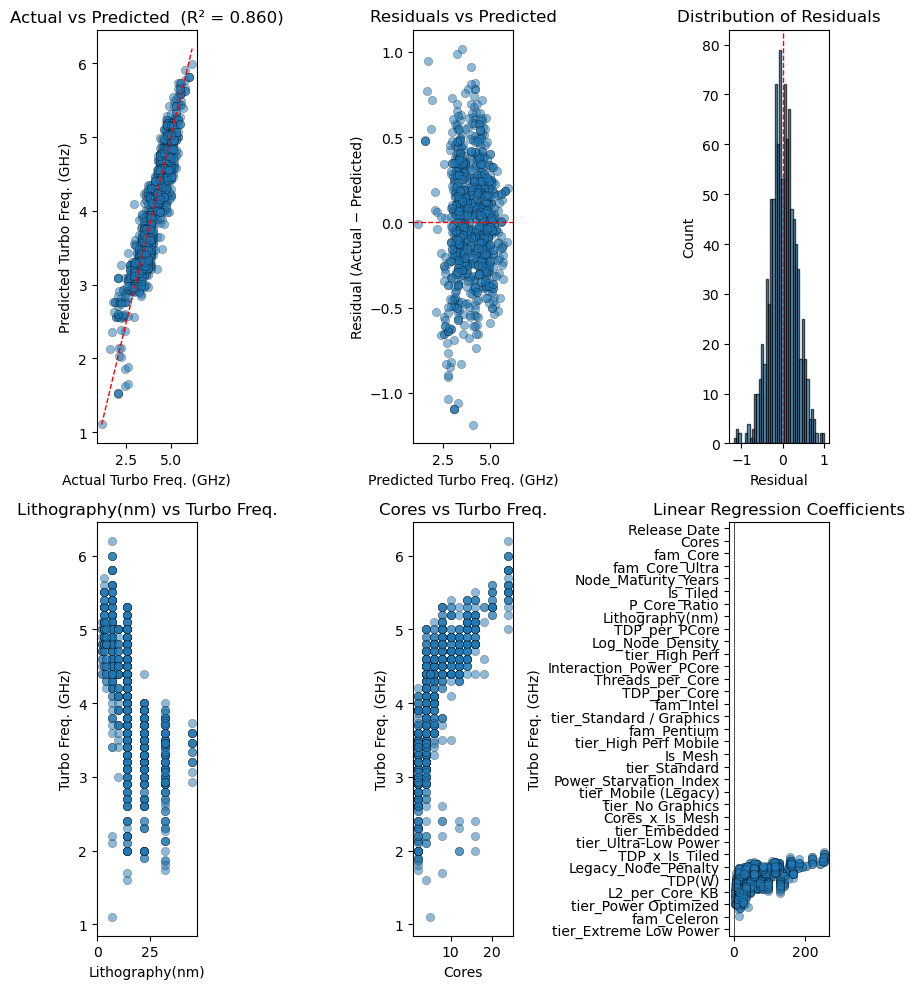

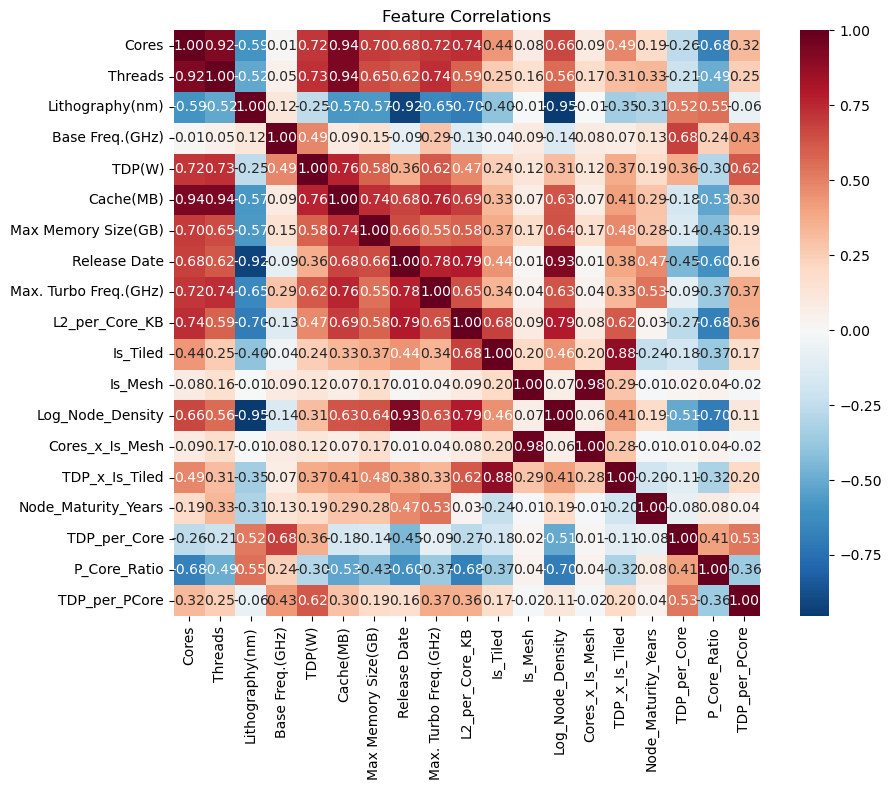

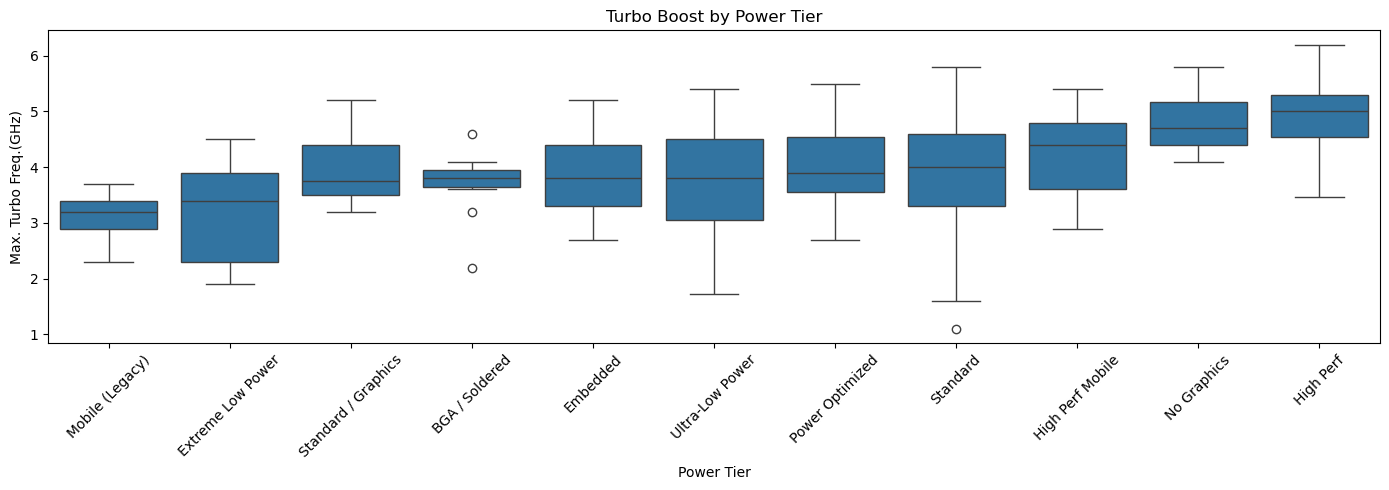

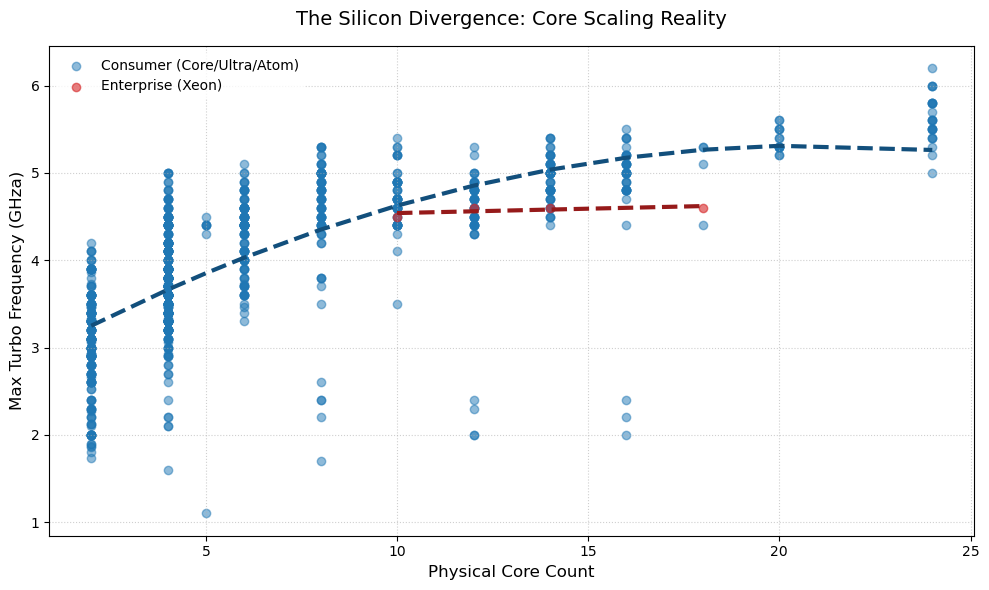

In [68]:
import matplotlib.pyplot as plt

# ── Predict ──────────────────────────────────────────────────
y_pred = model.predict(X_scaled)
residuals = y - y_pred

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1 ── Actual vs Predicted ────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y, y_pred, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1)
ax.set_xlabel("Actual Turbo Freq. (GHz)")
ax.set_ylabel("Predicted Turbo Freq. (GHz)")
ax.set_title(f"Actual vs Predicted  (R² = {r2_score(y, y_pred):.3f})")

# 2 ── Residuals vs Predicted ─────────────────────────────────
ax = axes[0, 1]
ax.scatter(y_pred, residuals, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.axhline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted Turbo Freq. (GHz)")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residuals vs Predicted")

# 3 ── Histogram of Residuals ─────────────────────────────────
ax = axes[0, 2]
ax.hist(residuals, bins=40, edgecolor="k", alpha=0.7)
ax.axvline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title("Distribution of Residuals")

# 4, 5, 6 ── Feature vs Target ────────────────────────────────
features = ["Lithography(nm)", "Cores", "TDP(W)"]
for i, (feat, ax) in enumerate(zip(features, [axes[1, 0], axes[1, 1], axes[1, 2]])):
    ax.scatter(X[feat], y, alpha=0.5, edgecolors="k", linewidth=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel("Turbo Freq. (GHz)")
    ax.set_title(f"{feat} vs Turbo Freq.")

coef_series = pd.Series(model.coef_, index=X.columns)
coef_series.sort_values().plot(kind="barh", figsize=(8, 10))
plt.axvline(0, color="k", linewidth=0.5)
plt.title("Linear Regression Coefficients")
plt.tight_layout()

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["Cores", "Threads", "Lithography(nm)", "Base Freq.(GHz)",
            "TDP(W)", "Cache(MB)", "Max Memory Size(GB)", "Release Date",
            "Max. Turbo Freq.(GHz)", "L2_per_Core_KB", "Is_Tiled", "Is_Mesh", "Log_Node_Density", "Cores_x_Is_Mesh", "TDP_x_Is_Tiled", "Node_Maturity_Years", "TDP_per_Core", "P_Core_Ratio", "TDP_per_PCore" ]

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="RdBu_r", center=0,
            fmt=".2f", square=True)
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
order = df.groupby("Power Tier")["Max. Turbo Freq.(GHz)"].median().sort_values().index
sns.boxplot(data=df, x="Power Tier", y="Max. Turbo Freq.(GHz)", order=order)
plt.xticks(rotation=45)
plt.title("Turbo Boost by Power Tier")
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import numpy as np

# Assuming 'df' is your original combined dataframe before you kicked out Xeons
# Let's create an explicit flag for coloring
df['Is_Xeon'] = df['Code Name'].map(gen_map).isin(['Xeon Scalable', 'Xeon Legacy'])

plt.figure(figsize=(10, 6), dpi=100)

# 1. Plot the raw data points colored by segment
consumer_df = df[~df['Is_Xeon']]
xeon_df = df[df['Is_Xeon']]

plt.scatter(consumer_df['Cores'], consumer_df['Max. Turbo Freq.(GHz)'], 
            alpha=0.5, color='#1f77b4', label='Consumer (Core/Ultra/Atom)')
plt.scatter(xeon_df['Cores'], xeon_df['Max. Turbo Freq.(GHz)'], 
            alpha=0.6, color='#d62728', label='Enterprise (Xeon)')

# 2. Calculate and plot independent trendlines (low-degree polynomial or linear)
# Consumer Trend
idx_c = np.argsort(consumer_df['Cores'])
p_c = np.poly1d(np.polyfit(consumer_df['Cores'], consumer_df['Max. Turbo Freq.(GHz)'], 2))
plt.plot(consumer_df['Cores'].iloc[idx_c], p_c(consumer_df['Cores'].iloc[idx_c]), 
         color='#124f7c', linewidth=3, linestyle='--')

# Xeon Trend
idx_x = np.argsort(xeon_df['Cores'])
p_x = np.poly1d(np.polyfit(xeon_df['Cores'], xeon_df['Max. Turbo Freq.(GHz)'], 1))
plt.plot(xeon_df['Cores'].iloc[idx_x], p_x(xeon_df['Cores'].iloc[idx_x]), 
         color='#961a1a', linewidth=3, linestyle='--')

plt.title('The Silicon Divergence: Core Scaling Reality', fontsize=14, pad=15)
plt.xlabel('Physical Core Count', fontsize=12)
plt.ylabel('Max Turbo Frequency (GHza)', fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)



plt.tight_layout()
plt.show()

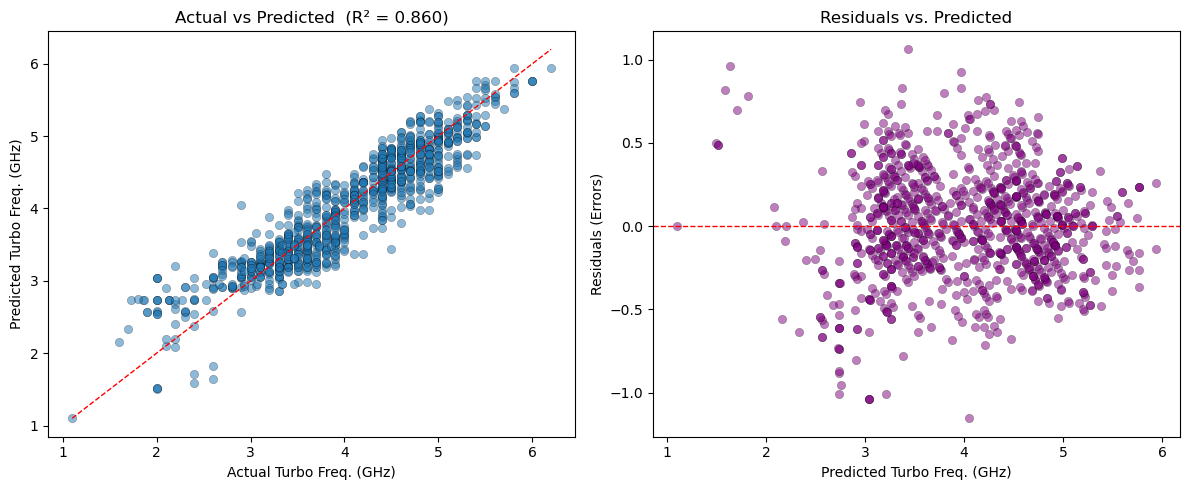

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ── Predict ──────────────────────────────────────────────────
y_pred = model.predict(X_scaled)
residuals = y - y_pred

# ── Fix: Initialize the subplot grid grid (1 row, 2 columns) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1 ── Actual vs Predicted ────────────────────────────────────
ax = axes[0]  # First subplot (left side)
ax.scatter(y, y_pred, alpha=0.5, edgecolors="k", linewidth=0.3)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1)
ax.set_xlabel("Actual Turbo Freq. (GHz)")
ax.set_ylabel("Predicted Turbo Freq. (GHz)")
ax.set_title(f"Actual vs Predicted  (R² = {r2_score(y, y_pred):.3f})")

# 2 ── Residuals Plot (Bonus room on the right!) ──────────────
ax2 = axes[1]  # Second subplot (right side)
ax2.scatter(y_pred, residuals, alpha=0.5, color='purple', edgecolors="k", linewidth=0.3)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax2.set_xlabel("Predicted Turbo Freq. (GHz)")
ax2.set_ylabel("Residuals (Errors)")
ax2.set_title("Residuals vs. Predicted")

plt.tight_layout()
plt.show()